In [2]:
import warnings
import tensorflow as tf, tensorflow_hub as hub
warnings.filterwarnings("ignore")
tf.get_logger().setLevel('ERROR')

print(tf.__version__)
model = hub.load("https://tfhub.dev/google/yamnet/1")
print("✅ loaded")


2.15.0
✅ loaded


In [3]:
import sounddevice as sd
sd.query_devices()

   0 Microsoft Sound Mapper - Input, MME (2 in, 0 out)
>  1 Microphone (3- High Definition , MME (2 in, 0 out)
   2 CABLE Output (VB-Audio Virtual , MME (16 in, 0 out)
   3 Microsoft Sound Mapper - Output, MME (0 in, 2 out)
<  4 Speakers (3- High Definition Au, MME (0 in, 6 out)
   5 CABLE Input (VB-Audio Virtual C, MME (0 in, 16 out)
   6 FxSound Speakers (FxSound Audio, MME (0 in, 8 out)
   7 PHL 221E9 (NVIDIA High Definiti, MME (0 in, 2 out)
   8 Digital Audio (S/PDIF) (3- High, MME (0 in, 2 out)
   9 Primary Sound Capture Driver, Windows DirectSound (2 in, 0 out)
  10 Microphone (3- High Definition Audio Device), Windows DirectSound (2 in, 0 out)
  11 CABLE Output (VB-Audio Virtual Cable), Windows DirectSound (16 in, 0 out)
  12 Primary Sound Driver, Windows DirectSound (0 in, 2 out)
  13 Speakers (3- High Definition Audio Device), Windows DirectSound (0 in, 6 out)
  14 CABLE Input (VB-Audio Virtual Cable), Windows DirectSound (0 in, 16 out)
  15 FxSound Speakers (FxSound Audio Enh

🎙️ Streaming detection start...
Inside, small room (0.12)


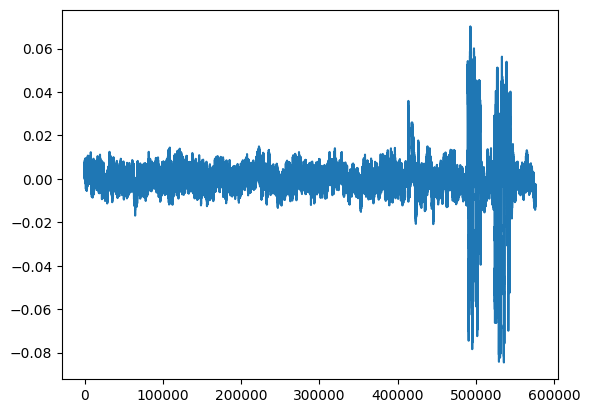

Inside, small room (0.12)


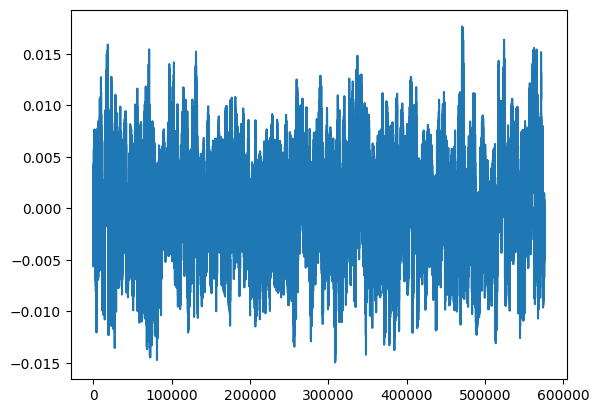

Inside, small room (0.13)


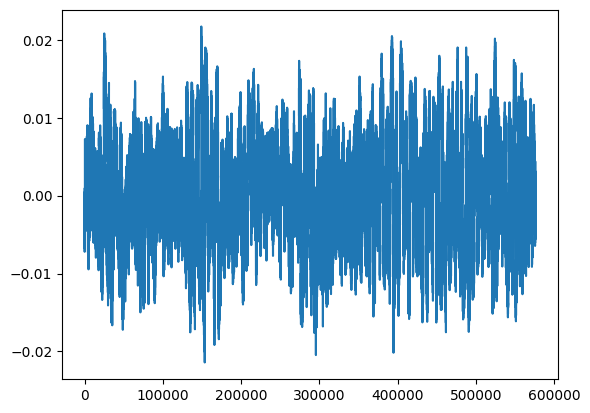

Inside, small room: 0.13
Aircraft: 0.09
Helicopter: 0.09
Drill: 0.09
Power tool: 0.09


In [5]:
import sounddevice as sd
import tensorflow as tf
import tensorflow_hub as hub
import pandas as pd
import matplotlib.pyplot as plt

# モデルとラベルを関数内で完結させる
def stream_detect(chunk=3, duration=10.0):
    sr = 192000
    sd.default.device = (24, None)
    model = hub.load("https://tfhub.dev/google/yamnet/1")
    url = "https://raw.githubusercontent.com/robertanto/Real-Time-Sound-Event-Detection/main/keras_yamnet/yamnet_class_map.csv"
    labels = pd.read_csv(url)['display_name'].tolist()

    print("🎙️ Streaming detection start...")
    with sd.InputStream(samplerate=sr, channels=1, dtype='float32') as stream:
        for _ in range(int(duration / chunk)):
            audio, _ = stream.read(int(sr * chunk))
            scores, _, _ = model(audio[:, 0])
            mean_scores = tf.reduce_mean(scores, axis=0)
            top = int(tf.argmax(mean_scores))
            label = labels[top]
            prob = float(mean_scores[top])
            print(f"{label} ({prob:.2f})")
            plt.plot(audio)
            plt.show()
    top5 = tf.argsort(mean_scores, direction='DESCENDING')[:5]
    for i in top5:
        print(f"{labels[int(i)]}: {mean_scores[i].numpy():.2f}")
stream_detect(chunk=3, duration=10.0)



In [8]:
import sounddevice as sd
import tensorflow as tf
import tensorflow_hub as hub
import pandas as pd
import numpy as np
import scipy.signal
import time

def stream_detect(threshold=0.7):

    mic_sr = 192000
    yamnet_sr = 16000
    chunk = 0.96
    cooldown = 2.0

    sd.default.device = (24, None)

    model = hub.load("https://tfhub.dev/google/yamnet/1")

    url = "https://raw.githubusercontent.com/robertanto/Real-Time-Sound-Event-Detection/main/keras_yamnet/yamnet_class_map.csv"
    labels = pd.read_csv(url)['display_name'].tolist()

    last_print = {}

    print("Streaming detection start")

    with sd.InputStream(samplerate=mic_sr, channels=1, dtype='float32') as stream:

        while True:

            audio, _ = stream.read(int(mic_sr * chunk))
            audio = audio[:, 0]

            audio = scipy.signal.resample_poly(audio, yamnet_sr, mic_sr)

            scores, _, _ = model(audio)

            mean_scores = tf.reduce_mean(scores, axis=0)

            top = int(tf.argmax(mean_scores))
            prob = float(mean_scores[top])
            label = labels[top]

            now = time.time()

            if prob >= threshold:

                if label not in last_print or now - last_print[label] > cooldown:
                    print(f"{label} ({prob:.2f})")
                    last_print[label] = now


stream_detect()

Streaming detection start
Speech (0.90)
Speech (0.71)
Speech (0.89)
Animal (0.97)


KeyboardInterrupt: 